# <wc_2018.csv> Exploration

- Downloaded from <https://gitlab.com/djh_or/2018-world-cup-stats/blob/master/world_cup_2018_stats.csv> on 6/28/26
- Unlike <wc_2022.csv>, this one has two rows for each game, as there's a duplicate entry for each team in the game. So total rows are 64 x 2 = 128.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
wc_2018 = pd.read_csv('wc_2018.csv')
wc_2018.head()

,Game,Group,Team,Opponent,Home/Away,Score,WDL,Pens?,Goals For,Goals Against,...,Passes Completed,Distance Covered km,Balls recovered,Tackles,Blocks,Clearances,Yellow cards,Red Cards,Second Yellow Card leading to Red Card,Fouls Committed
0,1,A,Russia,Saudi Arabia,home,5-0,W,NaN,5,0,...,240,118,53,9,3,19,1,0,0,22
1,1,A,Saudi Arabia,Russia,away,5-0,L,NaN,0,5,...,442,105,48,16,3,31,1,0,0,10
2,2,A,Egypt,Uruguay,home,0-1,L,NaN,0,1,...,308,112,57,12,4,32,2,0,0,12
3,2,A,Uruguay,Egypt,away,0-1,W,NaN,1,0,...,508,111,54,8,2,22,0,0,0,6
4,3,B,Morocco,IR Iran,home,0-1,L,NaN,0,1,...,371,101,38,9,1,16,1,0,0,22


In [4]:
team_list = wc_2018['Team'].unique()
team_list

<StringArray>
[        'Russia',   'Saudi Arabia',          'Egypt',        'Uruguay',
        'Morocco',        'IR Iran',       'Portugal',          'Spain',
         'France',      'Australia',      'Argentina',        'Iceland',
           'Peru',        'Denmark',        'Croatia',        'Nigeria',
     'Costa Rica',         'Serbia',        'Germany',         'Mexico',
         'Brazil',    'Switzerland',         'Sweden', 'Korea Republic',
        'Belgium',         'Panama',        'Tunisia',        'England',
       'Colombia',          'Japan',         'Poland',        'Senegal']
Length: 32, dtype: str

In [5]:
team_results_2018 = []
for team in team_list:
    games = 0
    goals_scored = 0
    goals_allowed = 0
    for i in range(wc_2018.shape[0]):
        if wc_2018.iloc[i, 2]==team:
            games += 1
            goals_scored += wc_2018.iloc[i, 8]
            goals_allowed += wc_2018.iloc[i, 9]
    score_average = (goals_scored/games - goals_allowed/games)
    team_results_2018.append([team, games, goals_scored, goals_allowed, score_average])
team_results_2018

[['Russia', 5, np.int64(11), np.int64(7), np.float64(0.8000000000000003)],
 ['Saudi Arabia', 3, np.int64(2), np.int64(7), np.float64(-1.666666666666667)],
 ['Egypt', 3, np.int64(2), np.int64(6), np.float64(-1.3333333333333335)],
 ['Uruguay', 5, np.int64(7), np.int64(3), np.float64(0.7999999999999999)],
 ['Morocco', 3, np.int64(2), np.int64(4), np.float64(-0.6666666666666666)],
 ['IR Iran', 3, np.int64(2), np.int64(2), np.float64(0.0)],
 ['Portugal', 4, np.int64(6), np.int64(6), np.float64(0.0)],
 ['Spain', 4, np.int64(7), np.int64(6), np.float64(0.25)],
 ['France', 7, np.int64(14), np.int64(6), np.float64(1.1428571428571428)],
 ['Australia', 3, np.int64(2), np.int64(5), np.float64(-1.0)],
 ['Argentina', 4, np.int64(6), np.int64(9), np.float64(-0.75)],
 ['Iceland', 3, np.int64(2), np.int64(5), np.float64(-1.0)],
 ['Peru', 3, np.int64(2), np.int64(2), np.float64(0.0)],
 ['Denmark', 4, np.int64(3), np.int64(2), np.float64(0.25)],
 ['Croatia', 7, np.int64(14), np.int64(9), np.float64(0.714

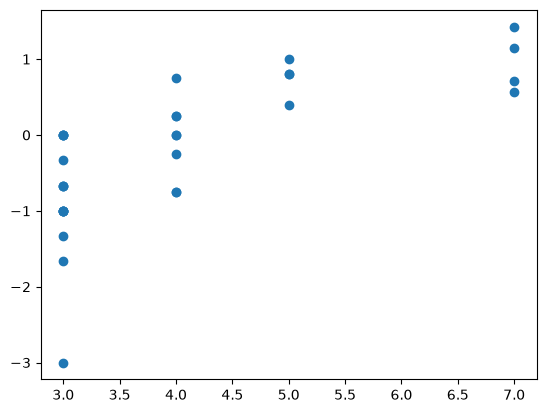

In [6]:
games_played = []
for i in range(len(team_results_2018)):
    games_played.append(team_results_2018[i][1])
score_average = []
for i in range(len(team_results_2018)):
    score_average.append(team_results_2018[i][4])
plt.scatter(games_played, score_average)

In [7]:
fifa_rankings = pd.read_csv('fifa_ranking-2024-06-20.csv')
fifa_rankings['rank_date'].unique

<bound method Series.unique of 0        1992-12-31
1        1992-12-31
2        1992-12-31
3        1992-12-31
4        1992-12-31
            ...    
67467    2024-06-20
67468    2024-06-20
67469    2024-06-20
67470    2024-06-20
67471    2024-06-20
Name: rank_date, Length: 67472, dtype: str>

In [8]:
rankings_2018 = fifa_rankings[fifa_rankings['rank_date']=='2018-06-07']
rankings_2018.head()

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
57583,206.0,Somalia,SOM,0.0,0.0,-1,CAF,2018-06-07
57584,204.0,British Virgin Islands,VGB,4.0,4.0,-2,CONCACAF,2018-06-07
57585,206.0,Bahamas,BAH,0.0,0.0,-1,CONCACAF,2018-06-07
57586,206.0,Anguilla,AIA,0.0,0.0,-1,CONCACAF,2018-06-07
57587,206.0,Eritrea,ERI,0.0,0.0,-1,CAF,2018-06-07


In [12]:
print("The last FIFA world rankings before the 2018 World Cup were posted on June 7th.")
print('Going into the 2018 World Cup, the team rankings were as follows:')
ranking_list=[]
for team in team_list:
    #print(team) #uncomment this line to test whether strings all match (they do!)
    for i in range(rankings_2018.shape[0]):
        if rankings_2018.iloc[i, 1].casefold() == team.casefold():
            print(f'{team}: {rankings_2018.iloc[i, 0]}')
            ranking_list.append(rankings_2018.iloc[i, 0])

The last FIFA world rankings before the 2018 World Cup were posted on June 7th.
Going into the 2018 World Cup, the team rankings were as follows:
Russia: 70.0
Saudi Arabia: 67.0
Egypt: 45.0
Uruguay: 14.0
Morocco: 41.0
IR Iran: 37.0
Portugal: 4.0
Spain: 10.0
France: 7.0
Australia: 36.0
Argentina: 5.0
Iceland: 22.0
Peru: 11.0
Denmark: 12.0
Croatia: 20.0
Nigeria: 48.0
Costa Rica: 23.0
Serbia: 34.0
Germany: 1.0
Mexico: 15.0
Brazil: 2.0
Switzerland: 6.0
Sweden: 24.0
Korea Republic: 57.0
Belgium: 3.0
Panama: 55.0
Tunisia: 21.0
England: 12.0
Colombia: 16.0
Japan: 61.0
Poland: 8.0
Senegal: 27.0


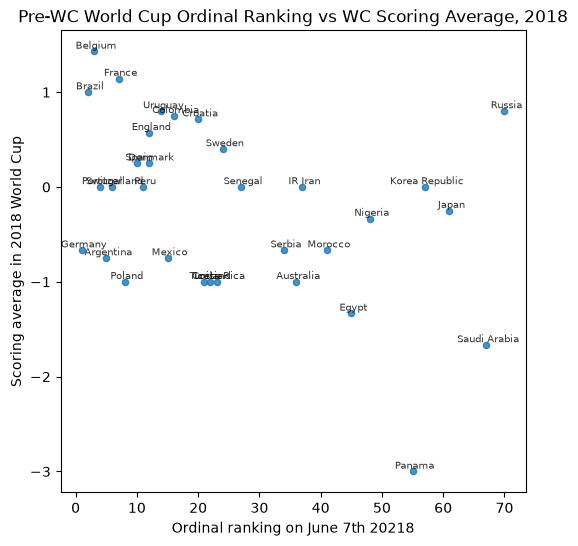

In [14]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(ranking_list, score_average, s=20, alpha = 0.8)
for i in range(len(team_list)):
    ax.annotate(team_list[i], xy=(ranking_list[i], score_average[i]), xytext=(1.5,2.0),
                ha='center', textcoords='offset points', size=7, alpha=0.8)
ax.set_xlabel('Ordinal ranking on June 7th 20218')
ax.set_ylabel('Scoring average in 2018 World Cup')
ax.set_title('Pre-WC World Cup Ordinal Ranking vs WC Scoring Average, 2018')
plt.show()


In [15]:
ordinal_data_matrix = np.array(ranking_list)
ones = np.ones((len(ranking_list), 1))
ordinal_data_matrix = np.transpose(np.vstack((np.array(ranking_list), np.ones((len(ranking_list))))))
ordinal_data_matrix

array([[70.,  1.],
       [67.,  1.],
       [45.,  1.],
       [14.,  1.],
       [41.,  1.],
       [37.,  1.],
       [ 4.,  1.],
       [10.,  1.],
       [ 7.,  1.],
       [36.,  1.],
       [ 5.,  1.],
       [22.,  1.],
       [11.,  1.],
       [12.,  1.],
       [20.,  1.],
       [48.,  1.],
       [23.,  1.],
       [34.,  1.],
       [ 1.,  1.],
       [15.,  1.],
       [ 2.,  1.],
       [ 6.,  1.],
       [24.,  1.],
       [57.,  1.],
       [ 3.,  1.],
       [55.,  1.],
       [21.,  1.],
       [12.,  1.],
       [16.,  1.],
       [61.,  1.],
       [ 8.,  1.],
       [27.,  1.]])

In [16]:
ordinal_coefs = np.linalg.lstsq(ordinal_data_matrix, score_average)
ordinal_coefs

(array([-0.01810386,  0.24251094]),
 array([22.69810807]),
 np.int32(2),
 array([183.80324133,   3.51688427]))

In [17]:
print(f'For the ordinal rankings, the regression residual is {ordinal_coefs[1]}')

For the ordinal rankings, the regression residual is [22.69810807]


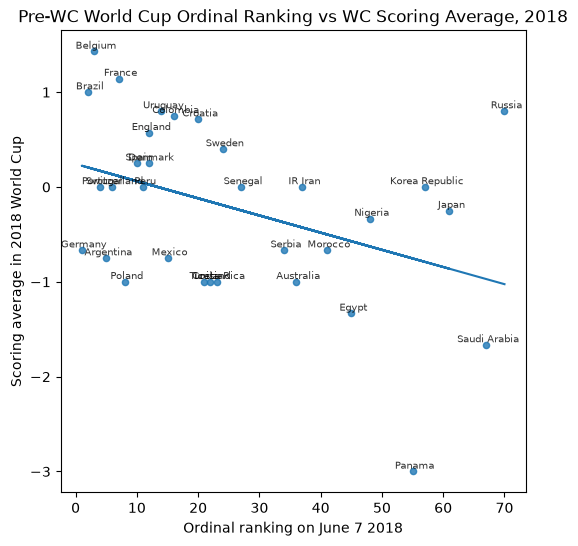

In [19]:
ord_slope, ord_intercept = ordinal_coefs[0]
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(ranking_list, score_average, s=20, alpha = 0.8)
for i in range(len(team_list)):
    ax.annotate(team_list[i], xy=(ranking_list[i], score_average[i]), xytext=(1.5,2.0),
                ha='center', textcoords='offset points', size=7, alpha=0.8)
ax.set_xlabel('Ordinal ranking on June 7 2018')
ax.set_ylabel('Scoring average in 2018 World Cup')
ax.set_title('Pre-WC World Cup Ordinal Ranking vs WC Scoring Average, 2018')
ax.plot(ranking_list, ord_slope*np.array(ranking_list) + ord_intercept)
plt.show()

In [20]:
print('Looking instead at total ranking points rather than the ordinal ranking:')
rpoints_list=[]
for team in team_list:
    for i in range(rankings_2018.shape[0]):
        if rankings_2018.iloc[i, 1].casefold() == team.casefold():
            print(f'{team}: {rankings_2018.iloc[i, 3]}')
            rpoints_list.append(rankings_2018.iloc[i, 3])

Looking instead at total ranking points rather than the ordinal ranking:
Russia: 457.0
Saudi Arabia: 465.0
Egypt: 649.0
Uruguay: 1018.0
Morocco: 686.0
IR Iran: 708.0
Portugal: 1274.0
Spain: 1126.0
France: 1198.0
Australia: 718.0
Argentina: 1241.0
Iceland: 908.0
Peru: 1125.0
Denmark: 1051.0
Croatia: 945.0
Nigeria: 618.0
Costa Rica: 884.0
Serbia: 751.0
Germany: 1558.0
Mexico: 989.0
Brazil: 1431.0
Switzerland: 1199.0
Sweden: 880.0
Korea Republic: 544.0
Belgium: 1298.0
Panama: 571.0
Tunisia: 910.0
England: 1051.0
Colombia: 986.0
Japan: 521.0
Poland: 1183.0
Senegal: 838.0


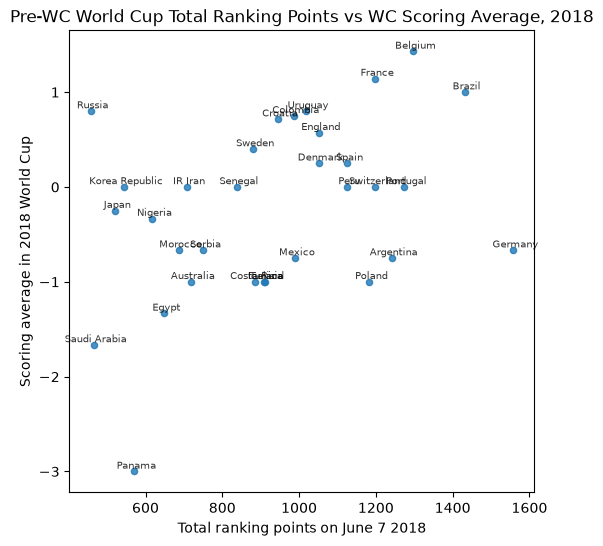

In [21]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(rpoints_list, score_average, s=20, alpha = 0.8)
for i in range(len(team_list)):
    ax.annotate(team_list[i], xy=(rpoints_list[i], score_average[i]), xytext=(1.5,2.0),
                ha='center', textcoords='offset points', size=7, alpha=0.8)
ax.set_xlabel('Total ranking points on June 7 2018')
ax.set_ylabel('Scoring average in 2018 World Cup')
ax.set_title('Pre-WC World Cup Total Ranking Points vs WC Scoring Average, 2018')
plt.show()

In [22]:
rpoints_data_matrix = np.array(rpoints_list)
ones = np.ones((len(rpoints_list), 1))
rpoints_data_matrix = np.transpose(np.vstack((np.array(rpoints_list), np.ones((len(rpoints_list))))))
rpoints_data_matrix

array([[4.570e+02, 1.000e+00],
       [4.650e+02, 1.000e+00],
       [6.490e+02, 1.000e+00],
       [1.018e+03, 1.000e+00],
       [6.860e+02, 1.000e+00],
       [7.080e+02, 1.000e+00],
       [1.274e+03, 1.000e+00],
       [1.126e+03, 1.000e+00],
       [1.198e+03, 1.000e+00],
       [7.180e+02, 1.000e+00],
       [1.241e+03, 1.000e+00],
       [9.080e+02, 1.000e+00],
       [1.125e+03, 1.000e+00],
       [1.051e+03, 1.000e+00],
       [9.450e+02, 1.000e+00],
       [6.180e+02, 1.000e+00],
       [8.840e+02, 1.000e+00],
       [7.510e+02, 1.000e+00],
       [1.558e+03, 1.000e+00],
       [9.890e+02, 1.000e+00],
       [1.431e+03, 1.000e+00],
       [1.199e+03, 1.000e+00],
       [8.800e+02, 1.000e+00],
       [5.440e+02, 1.000e+00],
       [1.298e+03, 1.000e+00],
       [5.710e+02, 1.000e+00],
       [9.100e+02, 1.000e+00],
       [1.051e+03, 1.000e+00],
       [9.860e+02, 1.000e+00],
       [5.210e+02, 1.000e+00],
       [1.183e+03, 1.000e+00],
       [8.380e+02, 1.000e+00]])

In [23]:
rpoints_coefs = np.linalg.lstsq(rpoints_data_matrix, score_average)
rpoints_coefs

(array([ 1.26721448e-03, -1.39734703e+00]),
 array([22.82587621]),
 np.int32(2),
 array([5.50467477e+03, 1.65241473e+00]))

In [24]:
print(f'Using ranking points, the regression residual is {rpoints_coefs[1]}')

Using ranking points, the regression residual is [22.82587621]


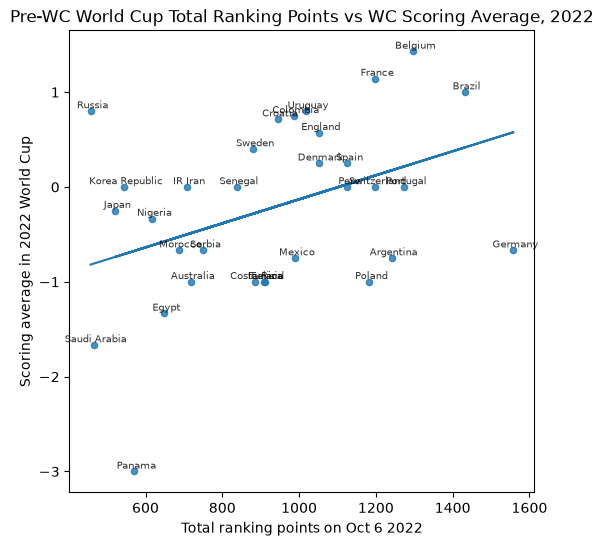

In [25]:
rpoints_slope, rpoints_intercept = rpoints_coefs[0]
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(rpoints_list, score_average, s=20, alpha = 0.8)
for i in range(len(team_list)):
    ax.annotate(team_list[i], xy=(rpoints_list[i], score_average[i]), xytext=(1.5,2.0),
                ha='center', textcoords='offset points', size=7, alpha=0.8)
ax.set_xlabel('Total ranking points on Oct 6 2022')
ax.set_ylabel('Scoring average in 2022 World Cup')
ax.set_title('Pre-WC World Cup Total Ranking Points vs WC Scoring Average, 2022')
ax.plot(rpoints_list, rpoints_slope*np.array(rpoints_list) + rpoints_intercept)
plt.show()